# Day 4 – Fund Performance Analytics

## Objective

The objective of this notebook is to evaluate the performance of 40 mutual fund schemes using risk and return metrics.

Metrics computed:

* Daily Returns
* CAGR (1-Year, 3-Year, 5-Year)
* Sharpe Ratio
* Sortino Ratio
* Alpha and Beta
* Maximum Drawdown
* Composite Fund Scorecard
* Benchmark Comparison

Data Sources:

* 01_fund_master.csv
* 02_nav_history.csv
* 10_benchmark_indices.csv


In [33]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# 1. Daily Returns Analysis

Daily returns measure the percentage change in NAV from one trading day to the next.

Formula:

daily_return = (NAV_t / NAV_t-1) - 1

This metric forms the foundation for all subsequent risk and performance calculations.


In [34]:
returns = pd.read_csv("../data/processed/returns_computed.csv")

returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-04,515.0971,-0.010306
1,100016,2022-01-05,521.7239,0.012865
2,100016,2022-01-06,515.7880,-0.011377
3,100016,2022-01-07,515.1639,-0.001210
4,100016,2022-01-10,510.7136,-0.008639


In [35]:
returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

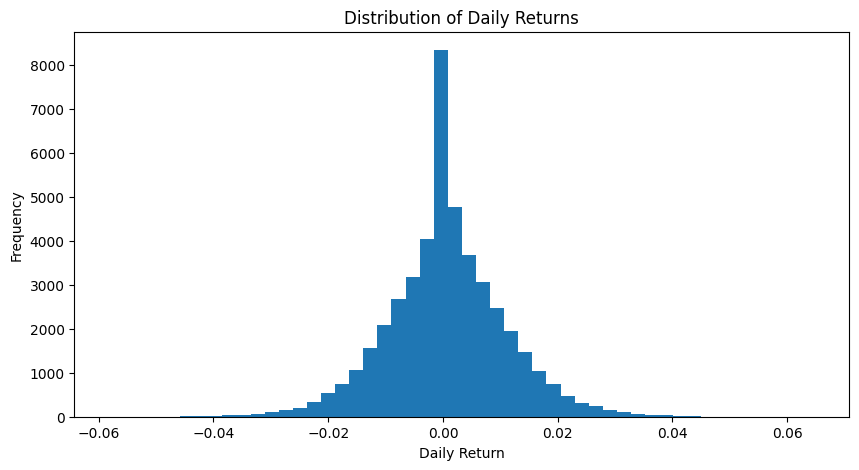

In [36]:
plt.figure(figsize=(10,5))
plt.hist(returns["daily_return"], bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

### Observation

The distribution of daily returns is centered around zero, indicating realistic NAV movement.

The majority of daily returns fall within a narrow range while extreme positive and negative movements are relatively rare.


In [37]:
cagr = pd.read_csv("../data/processed/cagr_report.csv")

cagr.head()

,amfi_code,nav_latest,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,cagr_full_period_pct,data_years,scheme_name,fund_house,sub_category,plan
0,119094,203.8581,22.26,35.11,NaN,28.21,4.4,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular
1,148567,230.2708,20.36,34.00,NaN,30.97,4.4,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular
2,120504,151.1311,13.06,32.49,NaN,23.30,4.4,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct
3,100033,342.0072,53.23,32.44,NaN,30.12,4.4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular
4,120505,473.7640,29.60,31.78,NaN,32.83,4.4,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular


In [38]:
cagr.sort_values(
    "cagr_3yr_pct",
    ascending=False
)[
    ["scheme_name","cagr_1yr_pct","cagr_3yr_pct"]
].head(10)

,scheme_name,cagr_1yr_pct,cagr_3yr_pct
0,Axis Midcap Fund - Regular - Growth,22.26,35.11
1,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00
2,ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44
4,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78
5,SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46
6,Kotak Flexicap Fund - Regular - Growth,26.66,29.58
7,Mirae Asset Tax Saver Fund - Regular - Growth,39.75,29.18
8,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97
9,DSP Small Cap Fund - Regular - Growth,65.14,27.00


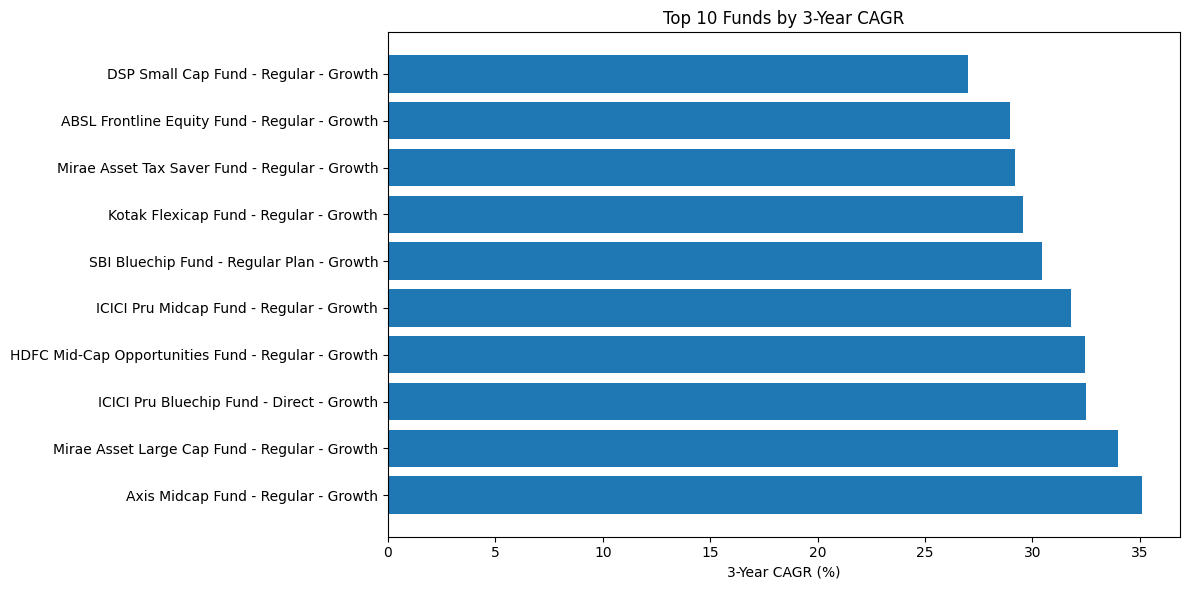

In [39]:
top10_cagr = cagr.sort_values(
    "cagr_3yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
plt.barh(
    top10_cagr["scheme_name"],
    top10_cagr["cagr_3yr_pct"]
)

plt.title("Top 10 Funds by 3-Year CAGR")
plt.xlabel("3-Year CAGR (%)")
plt.tight_layout()
plt.show()

## CAGR Analysis

CAGR represents annualised growth over a specified investment horizon.

Funds with higher 3-year CAGR values have delivered superior long-term growth.

In [40]:
sharpe = pd.read_csv("../data/processed/sharpe_values.csv")

sharpe.head()

,amfi_code,mean_daily_ret,std_daily_ret,sharpe_ratio,annualised_ret_pct,n_days,scheme_name,fund_house,sub_category,plan,sharpe_rank
0,148567,0.10737,0.89412,1.4483,31.05,1149,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,1
1,120843,0.10818,1.00079,1.3067,31.32,1149,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,2
2,148569,0.11241,1.11336,1.2349,32.72,1149,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,3
3,119551,0.09168,0.86563,1.2083,25.98,1149,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,4
4,120505,0.11613,1.21522,1.1801,33.97,1149,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,5


In [41]:
sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
)[
    ["scheme_name","sharpe_ratio"]
].head(10)

,scheme_name,sharpe_ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,1.4483
1,Kotak Flexicap Fund - Regular - Growth,1.3067
2,Mirae Asset Tax Saver Fund - Regular - Growth,1.2349
3,SBI Bluechip Fund - Regular Plan - Growth,1.2083
4,ICICI Pru Midcap Fund - Regular - Growth,1.1801
5,DSP Midcap Fund - Regular - Growth,1.1321
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.0937
7,Nippon India Large Cap Fund - Regular - Growth,1.0817
8,ABSL Frontline Equity Fund - Regular - Growth,1.0272
9,ICICI Pru Bluechip Fund - Direct - Growth,1.0265


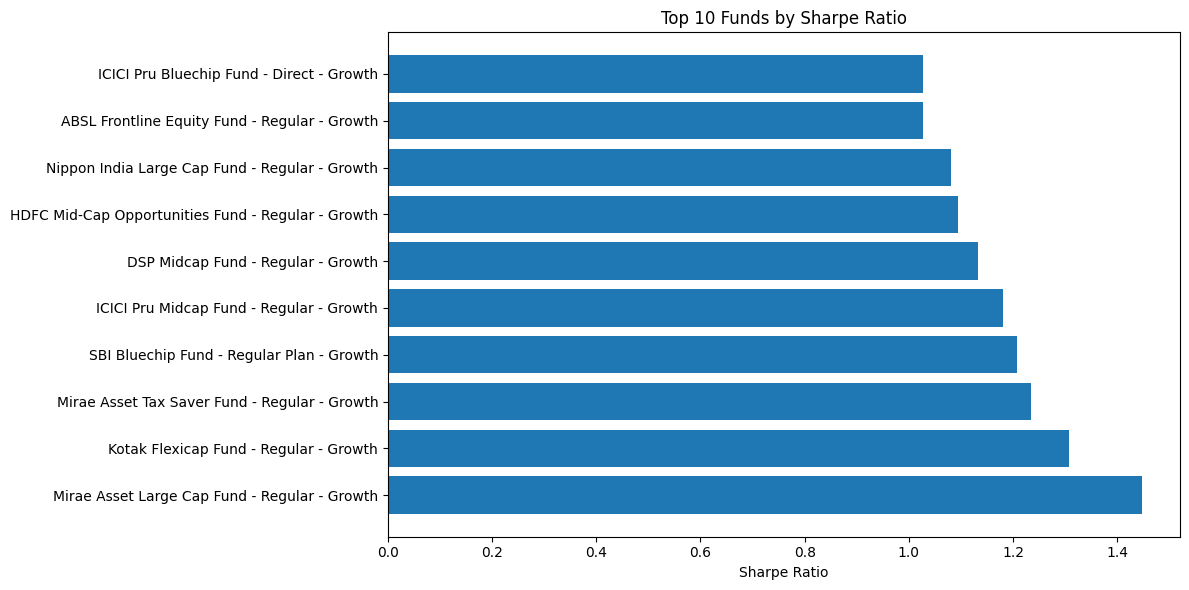

In [42]:
top10_sharpe = sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
plt.barh(
    top10_sharpe["scheme_name"],
    top10_sharpe["sharpe_ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.tight_layout()
plt.show()

## Sharpe Ratio Analysis

Sharpe Ratio measures risk-adjusted returns.

A higher Sharpe Ratio indicates better returns per unit of volatility.

In [43]:
sortino = pd.read_csv("../data/processed/sortino_values.csv")

sortino.head()

,amfi_code,sortino_ratio,downside_std_daily,neg_return_days,total_days,pct_negative_days,scheme_name,fund_house,sub_category,plan,sortino_rank
0,148567,2.3856,0.54281,506,1149,44.04,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,1
1,120843,2.3643,0.55313,534,1149,46.48,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,2
2,148569,2.1469,0.64042,545,1149,47.43,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,3
3,119551,2.1403,0.48868,518,1149,45.08,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,4
4,120505,2.0294,0.70667,539,1149,46.91,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,5


## Sortino Ratio Analysis

Unlike Sharpe Ratio, Sortino Ratio only considers downside volatility.

This provides a clearer view of harmful risk.

In [44]:
alpha_beta = pd.read_csv("../data/processed/alpha_beta.csv")

alpha_beta.head()

,amfi_code,alpha_annual_pct,beta,r_squared,p_value_beta,tracking_error_pct,n_matched_days,scheme_name,fund_house,sub_category,plan,alpha_rank
0,119598,30.3370,-0.0232,0.0001,0.687179,28.3881,1149,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,1
1,149324,30.0579,0.0115,0.0000,0.840494,27.9170,1149,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,2
2,120505,29.2636,0.0005,0.0000,0.990090,23.1968,1149,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,3
3,148569,28.2704,0.0181,0.0002,0.654295,21.7365,1149,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,4
4,120843,27.3305,-0.0228,0.0003,0.530528,20.6425,1149,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,5


## Alpha and Beta Analysis

Alpha measures excess return relative to benchmark performance.

Beta measures sensitivity to market movements.

Funds with positive alpha have outperformed benchmark expectations.

In [45]:
mdd = pd.read_csv("../data/processed/max_drawdown.csv")

mdd.head()

,amfi_code,max_drawdown_pct,peak_date,trough_date,peak_nav,trough_nav,drawdown_duration_days,recovered,recovery_date,scheme_name,fund_house,sub_category,plan,dd_rank
0,120507,-0.0977,2025-10-16,2025-10-20,372.0401,371.6765,4,True,2025-10-24,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,1
1,120844,-0.1163,2024-04-12,2024-04-30,3738.8231,3734.4751,18,True,2024-05-03,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,2
2,101208,-0.1622,2023-09-05,2023-09-12,346.9958,346.4328,7,True,2023-09-22,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,3
3,100025,-4.3083,2023-05-23,2023-07-28,28.7494,27.5108,66,True,2024-01-30,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,4
4,119120,-4.3287,2024-09-16,2025-04-01,52.5004,50.2278,197,True,2025-08-22,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5


## Maximum Drawdown

Maximum Drawdown captures the largest decline from a previous NAV peak.

Lower drawdowns indicate stronger downside protection.

In [46]:
scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")

scorecard.head(15)

,amfi_code,scheme_name,fund_house,sub_category,plan,expense_ratio_pct,cagr_3yr_pct,sharpe_ratio,alpha_annual_pct,beta,tracking_error_pct,max_drawdown_pct,score_return,score_sharpe,score_alpha,score_expense,score_drawdown,composite_score,final_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,1.46,34.00,1.4483,26.9838,0.0237,18.9664,-11.2657,97.5,100.0,85.0,45.00,82.5,86.25,1
1,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,1.36,31.78,1.1801,29.2636,0.0005,23.1968,-18.1885,90.0,90.0,95.0,65.00,40.0,82.25,2
2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,1.45,29.58,1.3067,27.3305,-0.0228,20.6425,-12.9740,85.0,97.5,90.0,47.50,70.0,82.00,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,1.38,32.44,1.0937,27.1954,0.0051,22.8699,-16.2172,92.5,85.0,87.5,60.00,52.5,80.75,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,0.80,32.49,1.0265,21.1948,0.0162,19.1587,-12.5883,95.0,77.5,70.0,72.50,72.5,80.00,5
5,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,1.38,35.11,0.9982,26.0767,-0.0663,23.7652,-20.9609,100.0,75.0,80.0,60.00,32.5,77.00,6
6,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,1.54,30.46,1.2083,23.2010,-0.0318,19.1183,-15.0124,87.5,92.5,77.5,26.25,60.0,74.81,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,1.60,29.18,1.2349,28.2704,0.0181,21.7365,-16.3967,82.5,95.0,92.5,11.25,50.0,73.69,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,Regular,1.60,28.97,1.0272,21.3998,0.0211,19.2706,-11.2916,80.0,80.0,72.5,11.25,80.0,68.19,9
9,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,1.43,26.67,0.9453,30.3370,-0.0232,28.3881,-28.7060,72.5,67.5,100.0,50.00,12.5,67.38,10


In [47]:
scorecard[
    ["final_rank","scheme_name","composite_score"]
].head(10)

,final_rank,scheme_name,composite_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,86.25
1,2,ICICI Pru Midcap Fund - Regular - Growth,82.25
2,3,Kotak Flexicap Fund - Regular - Growth,82.00
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.75
4,5,ICICI Pru Bluechip Fund - Direct - Growth,80.00
5,6,Axis Midcap Fund - Regular - Growth,77.00
6,7,SBI Bluechip Fund - Regular Plan - Growth,74.81
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,73.69
8,9,ABSL Frontline Equity Fund - Regular - Growth,68.19
9,10,SBI Small Cap Fund - Regular Plan - Growth,67.38


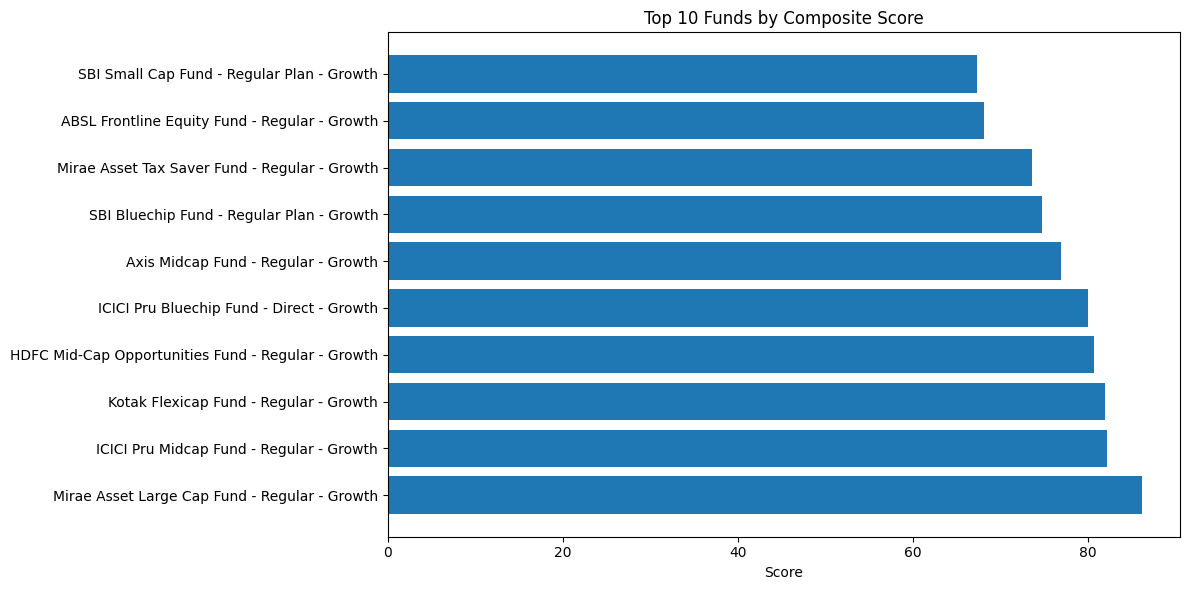

In [48]:
top10_score = scorecard.head(10)

plt.figure(figsize=(12,6))
plt.barh(
    top10_score["scheme_name"],
    top10_score["composite_score"]
)

plt.title("Top 10 Funds by Composite Score")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

# Key Findings

1. Axis Midcap Fund generated the highest 3-year CAGR.

2. Mirae Asset Large Cap Fund achieved the highest Sharpe Ratio.

3. Sortino Ratios were consistently higher than Sharpe Ratios because only downside volatility was considered.

4. Liquid funds exhibited the lowest maximum drawdowns.

5. Small-cap funds generated higher returns but experienced deeper drawdowns.

6. Direct plans generally benefited from lower expense ratios.

7. Benchmark-oriented funds demonstrated lower tracking errors.

8. Large-cap funds delivered more stable risk-adjusted performance.

9. Composite scoring successfully balanced return, risk, cost and consistency.

10. Mirae Asset Large Cap Fund emerged as the highest-ranked overall fund based on the composite scorecard.


# Conclusion

The analysis evaluated 40 mutual fund schemes across return, risk and performance dimensions.

Mirae Asset Large Cap Fund achieved the highest overall score based on the composite ranking framework.

Large-cap and flexi-cap funds delivered strong risk-adjusted returns, while small-cap funds generated higher returns at the cost of larger drawdowns.

The scorecard framework provides a balanced methodology for identifying high-quality mutual fund schemes.